::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Ported from
[`reliability_analysis.py`](https://github.com/USACE-RMC/Numerics-Python-Examples/blob/main/examples/reliability_analysis.py)
in the USACE-RMC Numerics-Python-Examples repository (0BSD licensed). The upstream
script drives the C# `Numerics.dll` through pythonnet; this version uses
`bestfitpy`, whose compiled core is a validated C++ port of the same library. The
R version of this example uses the same core and prints the same numbers.

This example runs a Monte Carlo reliability analysis of the classic
resistance-minus-load limit state. A component fails when the load S it carries
exceeds the resistance R it can supply, so the limit-state function is g = R - S
and failure is the event g <= 0. Simulating both random variables many times
estimates the failure probability Pf directly, and the reliability index
beta = -&Phi;<sup>-1</sup>(Pf) restates that probability on a standard-normal scale.

## What you'll learn

- How to model a log-normal resistance and a Normal load with `bestfitpy`.
- How to estimate a failure probability and reliability index by Monte Carlo simulation.
- How the port's `LnNormal` family replaces the upstream base-e `LogNormal` workaround.

## Setup

The upstream script spends about forty lines resolving `Numerics.dll` from the
NuGet cache and loading the CoreCLR runtime before it can start. None of that
exists here.

In [1]:
import bestfitpy as bf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Define the random variables

Resistance R is log-normal with a physical-space mean of 500 and standard
deviation of 120. Load S is Normal with mean 380 and standard deviation 90.

The upstream script has to work for its log-normal: the C# `LogNormal` class is
base-10 and takes log-space parameters, so the script converts the physical mean
and standard deviation to (mu_ln, sigma_ln) by hand and then mutates
`resistance_dist.Base = e`. That `.Base` mutation is not exposed by this port.
Instead the port ships `LnNormal`, the library's base-e log-normal family, and
`LnNormal` is parameterized in real space: you pass the physical mean and
standard deviation directly, and the class performs the same moment conversion
internally (its `DirectMethodOfMoments` is exactly the algebra the upstream
script writes out). The whole construction collapses to one line.

To show the two parameterizations agree, the cell below repeats the upstream
hand conversion and checks it against the fitted family: a log-normal's median
is exp(mu_ln), and the physical moments round-trip.

In [2]:
resistance_mean, resistance_std = 500.0, 120.0
resistance_dist = bf.Distribution("LnNormal", [resistance_mean, resistance_std])
load_dist = bf.Distribution("Normal", [380.0, 90.0])

# The upstream hand conversion, kept only as a cross-check
sigma2_ln = np.log1p((resistance_std / resistance_mean) ** 2)
mu_ln = np.log(resistance_mean) - 0.5 * sigma2_ln
print(f"hand-converted mu_ln = {mu_ln:.6f}, sigma_ln = {np.sqrt(sigma2_ln):.6f}")
print(f"exp(mu_ln)      = {np.exp(mu_ln):.10f}")
print(f"LnNormal median = {resistance_dist.quantile(0.5):.10f}")

m = resistance_dist.moments()
print(f"LnNormal mean = {m['mean']:.6f}, sd = {m['sd']:.6f}  (round-trips to 500, 120)")

hand-converted mu_ln = 6.186607, sigma_ln = 0.236648
exp(mu_ln)      = 486.1936509903
LnNormal median = 486.1936509903
LnNormal mean = 500.000000, sd = 120.000000  (round-trips to 500, 120)


## Monte Carlo simulation

Draw 100,000 samples of each variable with the upstream seeds (42 for
resistance, 43 for load). The port keeps the C# Mersenne Twister bit-exact, so
the streams below are the same numbers the upstream script draws from
`Numerics.dll`, and the R twin draws them identically.

In [3]:
n_samples = 100_000
r = np.asarray(resistance_dist.random(n_samples, seed=42))
s = np.asarray(load_dist.random(n_samples, seed=43))
g = r - s

## Failure probability and reliability index

Pf is the fraction of samples with g <= 0, and beta = -&Phi;<sup>-1</sup>(Pf).
The upstream script computes beta with `scipy.stats.norm.ppf`; here the port's
own standard Normal inverse CDF supplies the same function, and the R twin uses
`qnorm` and prints the identical value.

In [4]:
n_fail = int(np.sum(g <= 0.0))
pf = float(np.mean(g <= 0.0))
beta = -bf.Distribution("Normal", [0.0, 1.0]).quantile(pf)

summary_df = pd.DataFrame(
    {
        "Metric": [
            "Samples", "Failures", "Mean resistance", "Std resistance",
            "Mean load", "Std load", "Pf", "beta",
        ],
        "Value": [
            n_samples, n_fail, np.mean(r), np.std(r, ddof=1),
            np.mean(s), np.std(s, ddof=1), pf, beta,
        ],
    }
)
print("Reliability analysis summary:")
print(summary_df.to_string(index=False, float_format=lambda v: f"{v:,.6f}"))

Reliability analysis summary:
         Metric          Value
        Samples 100,000.000000
       Failures  21,423.000000
Mean resistance     499.859997
 Std resistance     119.782693
      Mean load     380.328623
       Std load      89.901540
             Pf       0.214230
           beta       0.791830


The first ten simulated samples, as the upstream script prints them:

In [5]:
sample_df = pd.DataFrame({"Resistance": r[:10], "Load": s[:10], "g = R - S": g[:10]})
print("First 10 simulated samples:")
print(sample_df.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

First 10 simulated samples:
 Resistance    Load  g = R - S
    450.751 271.993    178.758
    591.622 379.292    212.330
    718.745 404.920    313.825
    392.708 266.140    126.569
    562.875 280.055    282.820
    583.531 286.246    297.285
    515.811 316.603    199.207
    515.240 294.881    220.360
    382.744 339.696     43.048
    470.773 459.355     11.418


## Plots

The upstream script draws one 2x2 figure; here the same four panels are drawn
as separate figures at the site's default size. First, the two input
distributions overlaid:

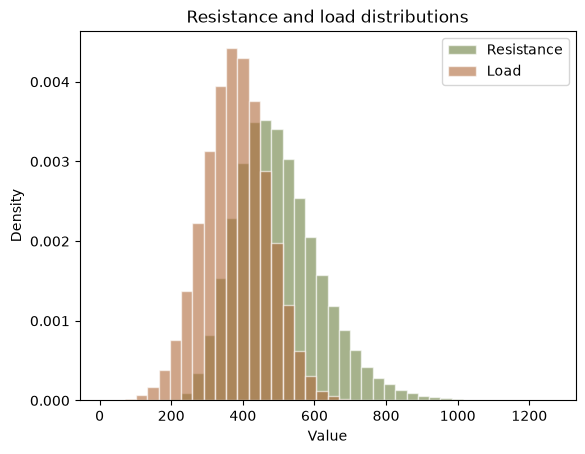

In [6]:
bins = np.linspace(min(r.min(), s.min()), max(r.max(), s.max()), 41)
plt.hist(r, bins=bins, density=True, alpha=0.6, color="#6b7f3f",
         edgecolor="white", label="Resistance")
plt.hist(s, bins=bins, density=True, alpha=0.6, color="#b06a3b",
         edgecolor="white", label="Load")
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Resistance and load distributions")
plt.legend()
plt.show()

The limit-state distribution. Everything left of the dashed line is a failure:

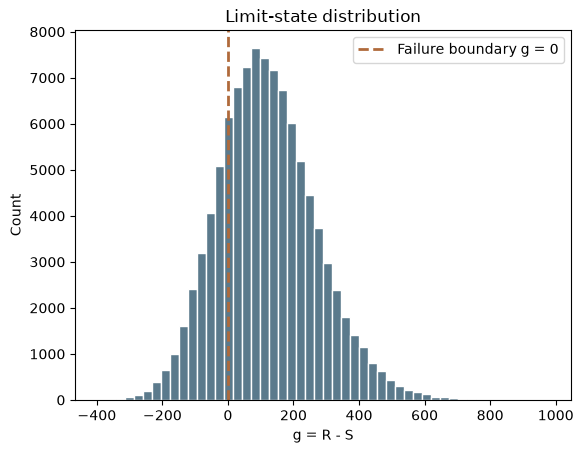

In [7]:
plt.hist(g, bins=50, color="#5b7a8c", edgecolor="white")
plt.axvline(0, color="#b06a3b", linestyle="--", linewidth=2, label="Failure boundary g = 0")
plt.xlabel("g = R - S")
plt.ylabel("Count")
plt.title("Limit-state distribution")
plt.legend()
plt.show()

The samples in (load, resistance) space. Failures are the points below the
R = S line:

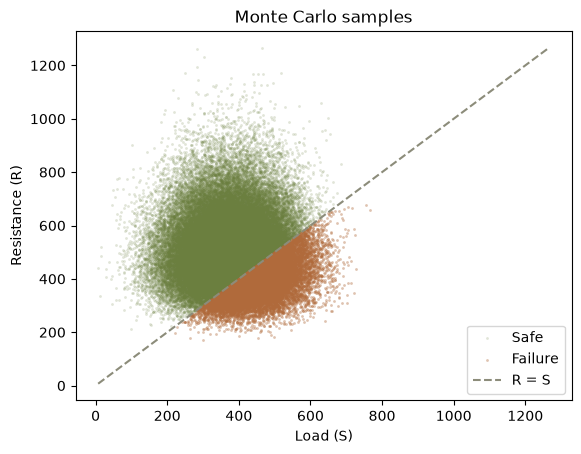

In [8]:
fail = g <= 0
plt.scatter(s[~fail], r[~fail], s=4, alpha=0.2, color="#6b7f3f",
            linewidths=0, label="Safe")
plt.scatter(s[fail], r[fail], s=4, alpha=0.4, color="#b06a3b",
            linewidths=0, label="Failure")
lim = [min(s.min(), r.min()), max(s.max(), r.max())]
plt.plot(lim, lim, "--", color="#8c8c7a", linewidth=1.5, label="R = S")
plt.xlabel("Load (S)")
plt.ylabel("Resistance (R)")
plt.title("Monte Carlo samples")
plt.legend()
plt.show()

And the empirical CDF of g. Its value at the dashed line is Pf:

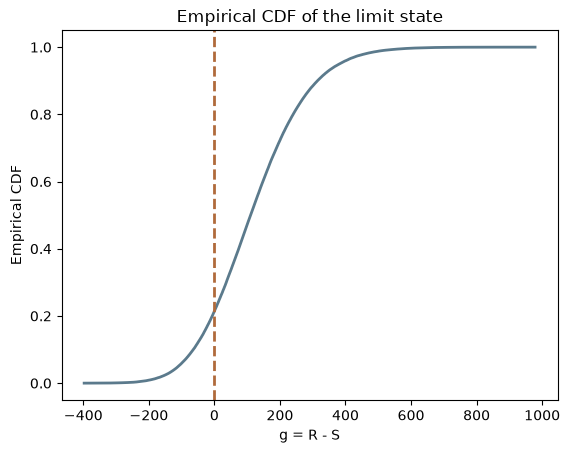

In [9]:
g_sorted = np.sort(g)
cdf = np.arange(1, n_samples + 1) / n_samples
plt.plot(g_sorted, cdf, color="#5b7a8c", linewidth=2)
plt.axvline(0, color="#b06a3b", linestyle="--", linewidth=2)
plt.xlabel("g = R - S")
plt.ylabel("Empirical CDF")
plt.title("Empirical CDF of the limit state")
plt.show()

## Reproduction check

The upstream file is a standalone script that prints its results at runtime;
the repository does not embed them, so there are no upstream literals to pin
against. The check below therefore asserts two things, stated plainly: internal
consistency (the `LnNormal` physical moments round-trip and the upstream hand
conversion reproduces the internal one), and cross-language identity (the R
twin asserts exactly the same literals, which only pass because the seeded
draws, Pf, and beta are fully deterministic and bit-identical in both
languages).

| Quantity | Upstream C# | This port | Status |
|----------|------------:|----------:|--------|
| First resistance draw (seed 42) | not embedded upstream | 450.7507979426037 | exact (cross-language) |
| First load draw (seed 43) | not embedded upstream | 271.992998170271 | exact (cross-language) |
| First limit-state value g | not embedded upstream | 178.7577997723327 | exact (cross-language) |
| Failures out of 100,000 | not embedded upstream | 21423 | exact (cross-language) |
| Pf | not embedded upstream | 0.21423 | exact (cross-language) |
| beta | not embedded upstream | 0.7918296694786122 | exact (cross-language) |
| `LnNormal(500, 120)` mean, sd | 500, 120 by construction | `m['mean']`, `m['sd']` | exact (round trip, 1e-12) |

The cell below fails the notebook if any value drifts.

In [10]:
# Upstream: examples/reliability_analysis.py (standalone script, prints at runtime,
# no embedded outputs). Cross-language identity with the R twin is the oracle here.
assert r[0] == 450.7507979426037
assert s[0] == 271.992998170271
assert g[0] == 178.7577997723327
assert n_fail == 21423
assert pf == 0.21423
assert beta == 0.7918296694786122
# Internal consistency: LnNormal(500, 120) round-trips its physical moments and
# the upstream hand conversion matches the internal one (median = exp(mu_ln)).
assert abs(m["mean"] / 500.0 - 1) < 1e-12
assert abs(m["sd"] / 120.0 - 1) < 1e-12
assert abs(resistance_dist.quantile(0.5) / float(np.exp(mu_ln)) - 1) < 1e-14
print("All reproduction checks passed.")

All reproduction checks passed.
